In [ ]:
import os
from PIL import Image
import numpy as numpy
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans



In [5]:
import numpy as np
import matplotlib.pyplot as plt
import cv2
import os

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
from tensorflow.keras.layers import Layer

In [3]:
import torch

# ROCm 환경에서 GPU 확인
if torch.backends.mps.is_available():  # Metal Performance Shaders (Mac 전용)
    device = torch.device('mps')  # macOS에서 MPS 지원 GPU 사용
    print("Using MPS on macOS")
elif torch.backends.hip.is_available():  # ROCm 지원
    device = torch.device('cuda')  # ROCm에서는 'cuda' 장치를 사용
    print("Using ROCm on AMD GPU")
else:
    device = torch.device('cpu')
    print("Using CPU")

Using MPS on macOS


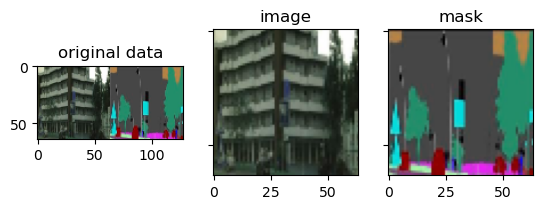

In [7]:
img_path = '/Users/sunghyunkim/Desktop/sung hyun/개발/동아리 및 스터디/GDG동아리/week8/cityscapes_data/train/1.jpg'
img = cv2.imread(img_path)
img = cv2.resize(img, (128, 128))

f, (ax1, ax2, ax3) = plt.subplots(1, 3, sharey=True)
ax1.set_title('original data')
ax1.imshow(img);
ax2.set_title('image')
ax2.imshow(img[0:64, 0:64]);
ax3.set_title('mask')
ax3.imshow(img[0:64, 64:128]);

In [13]:
import os
import cv2

def preprocess_images(path):
    X_data = []
    Y_data = []
    
    # Ensure the path ends with a slash
    directory = path if path.endswith('/') else path + '/'

    for image in os.listdir(directory):
        file_path = os.path.join(directory, image)
        
        # Check if the file is an image
        if not (image.endswith('.png') or image.endswith('.jpg') or image.endswith('.jpeg')):
            print(f"Skipping non-image file: {file_path}")
            continue

        # Read the image
        img = cv2.imread(file_path)
        
        if img is None:
            print(f"Failed to read image: {file_path}")
            continue
        
        # Resize the image
        try:
            img = cv2.resize(img, (128, 128))
        except Exception as e:
            print(f"Error resizing image {file_path}: {e}")
            continue

        # Example: Splitting into train and cropped regions (adjust as needed)
        cropped_image_train = img[0:64, 0:64]
        X_data.append(cropped_image_train)
        Y_data.append(img[64:128, 64:128])  # Example operation

    return X_data, Y_data

In [14]:
X_train, Y_train = preprocess_images("/Users/sunghyunkim/Desktop/sung hyun/개발/동아리 및 스터디/GDG동아리/week8/cityscapes_data/train")
X_valid, Y_valid = preprocess_images("/Users/sunghyunkim/Desktop/sung hyun/개발/동아리 및 스터디/GDG동아리/week8/cityscapes_data/val")

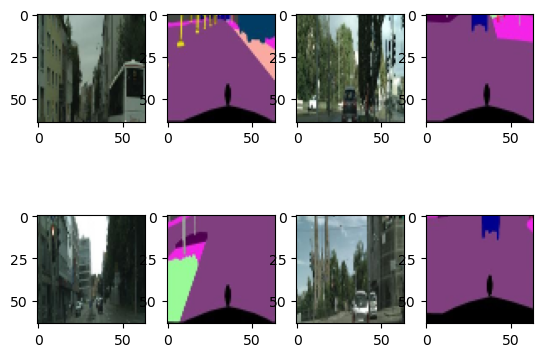

In [16]:

plt.subplot(2, 4, 1)
plt.imshow(cv2.cvtColor(X_train[0], cv2.COLOR_BGR2RGB));
plt.subplot(2, 4, 2)
plt.imshow(cv2.cvtColor(Y_train[0], cv2.COLOR_BGR2RGB));
plt.subplot(2, 4, 3)
plt.imshow(cv2.cvtColor(X_train[1], cv2.COLOR_BGR2RGB));
plt.subplot(2, 4, 4)
plt.imshow(cv2.cvtColor(Y_train[1], cv2.COLOR_BGR2RGB));
plt.subplot(2, 4, 5)
plt.imshow(cv2.cvtColor(X_train[2], cv2.COLOR_BGR2RGB));
plt.subplot(2, 4, 6)
plt.imshow(cv2.cvtColor(Y_train[2], cv2.COLOR_BGR2RGB));
plt.subplot(2, 4, 7)
plt.imshow(cv2.cvtColor(X_train[3], cv2.COLOR_BGR2RGB));
plt.subplot(2, 4, 8)
plt.imshow(cv2.cvtColor(Y_train[3], cv2.COLOR_BGR2RGB));

In [18]:
X_train = np.array(X_train, dtype='float32')/255.0
Y_train = np.array(Y_train, dtype='float32')/255.0
X_valid = np.array(X_valid, dtype='float32')/255.0
Y_valid = np.array(Y_valid, dtype='float32')/255.0

In [19]:
def ConvBlock(x, n_filters):
    # Taking first input and implementing the first conv block
    x = layers.Conv2D(n_filters, 3, padding='same', activation='relu', kernel_initializer='he_normal')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Conv2D(n_filters, 3, padding='same', activation='relu', kernel_initializer='he_normal')(x)
    x = layers.BatchNormalization()(x)
    
    return x

In [20]:
def downsample_block(x, n_filters):
    f = ConvBlock(x, n_filters)
    p = layers.MaxPool2D(2)(f)
    p = layers.Dropout(0.3)(p)
    return f, p

In [21]:

def upsample_block(x, conv_features, n_filters):
    x = layers.Conv2DTranspose(n_filters, 3, 2, padding='same')(x)
    x = layers.concatenate([x, conv_features])
    x = layers.Dropout(0.3)(x)
    x = ConvBlock(x, n_filters)
    return x

In [22]:
X_train[0].shape

(64, 64, 3)

In [25]:
def build_unet_model(output_channels):
    #input layer
    inputs = layers.Input(shape=(64, 64, 3))
    #encoder : downsample
    f1, p1 = downsample_block(inputs, 32)
    f2, p2 = downsample_block(p1, 64)
    f3, p3 = downsample_block(p2, 128)
    f4, p4 = downsample_block(p3, 256)
    #intermediate block
    intermediate_block = ConvBlock(p4, 512)
    #decoder : upsamle
    u6 = upsample_block(intermediate_block, f4, 256)
    u7 = upsample_block(u6, f3, 128)
    u8 = upsample_block(u7, f2, 64)
    u9 = upsample_block(u8, f1, 32)
    #output layer
    outputs = layers.Conv2D(output_channels, 1, padding='same', activation='sigmoid')(u9)
    #unet model
    unet_model = tf.keras.Model(inputs, outputs, name='U-Net')
    return unet_model

In [29]:
output_channels = 3
model = build_unet_model(output_channels)
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
tf.keras.utils.plot_model(model, show_shapes=True, expand_nested=False, dpi=64)


You must install pydot (`pip install pydot`) and install graphviz (see instructions at https://graphviz.gitlab.io/download/) for plot_model to work.


1/1 [==============================] - 0s 170ms/step


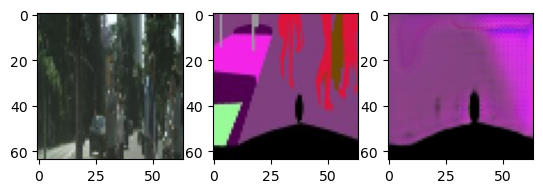

In [32]:
image_id_test = 32
X_tmp = X_valid[image_id_test]
X_tmp = np.expand_dims(X_tmp, axis=0)

y_tmp = model.predict(X_tmp)

plt.subplot(1, 3, 1)
plt.imshow(cv2.cvtColor(X_valid[image_id_test], cv2.COLOR_BGR2RGB))
plt.subplot(1, 3, 2)
plt.imshow(cv2.cvtColor(Y_valid[image_id_test], cv2.COLOR_BGR2RGB))
plt.subplot(1, 3, 3)
plt.imshow(cv2.cvtColor(y_tmp[0], cv2.COLOR_BGR2RGB))